In [231]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [232]:
countries = pd.read_csv(r"C:\Users\LENOVO\Downloads\British Airways\Countries.csv")
ba_reviews = pd.read_csv(r"C:\Users\LENOVO\Downloads\British Airways\ba_reviews.csv")

In [233]:
countries.head(10)

,Country,Code,Continent,Region
0,Afghanistan,AFG,Asia,Southern Asia
1,Åland Islands,ALA,Europe,Northern Europe
2,Albania,ALB,Europe,Southern Europe
3,Algeria,DZA,Africa,Northern Africa
4,American Samoa,ASM,Oceania,Polynesia
5,Andorra,AND,Europe,Southern Europe
6,Angola,AGO,Africa,Middle Africa
7,Anguilla,AIA,North America,Caribbean
8,Antarctica,ATA,Antarctica,Antarctica
9,Antigua and Barbuda,ATG,North America,Caribbean


In [234]:
ba_reviews.head()

,header,author,date,place,content,aircraft,traveller_type,seat_type,route,date_flown,recommended,trip_verified,rating,seat_comfort,cabin_staff_service,food_beverages,ground_service,value_for_money,entertainment
0,service was mediocre at best,Gary Storer,03/10/2023,United Kingdom,"Just returned from Chicago, flew out 10 days ...",A380,Couple Leisure,Economy Class,Chicago to Manchester via Heathrow,01/10/2023,no,Not Verified,2,2,3,1,2,2,-1
1,BA standards continue to decline,A Jensen,02/10/2023,United Kingdom,BA standards continue to decline every time ...,A320,Business,Business Class,London Heathrow to Munich,01/09/2023,no,Verified,2,2,1,2,1,1,-1
2,"won the race to the bottom""",John Rockett,02/10/2023,United Kingdom,Awful. Business class check in queue just as...,A320,Couple Leisure,Business Class,Heathrow to Istanbul,01/09/2023,no,Not Verified,2,2,3,2,1,1,-1
3,Not a reliable airline,Tatiana Bobrovskaya,02/10/2023,United Kingdom,Not a reliable airline. You cannot trust the...,A320,Business,Economy Class,London to Geneva,01/10/2023,no,Verified,3,4,4,2,1,1,-1
4,Very disappointed,Tom Slowbe,28/09/2023,United States,"The airplanes and the lounges are worn out, o...",777-300 and A320,Couple Leisure,First Class,Dallas to Dubrovnik via Heathrow,01/09/2023,no,Verified,1,1,4,4,3,2,3


In [235]:
print(countries.shape)
print(countries.info())
print(countries.describe())

(251, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Country    251 non-null    object
 1   Code       250 non-null    object
 2   Continent  251 non-null    object
 3   Region     251 non-null    object
dtypes: object(4)
memory usage: 8.0+ KB
None
            Country Code Continent     Region
count           251  250       251        251
unique          251  249         7         23
top     Afghanistan  HKG    Africa  Caribbean
freq              1    2        60         28


In [236]:
print(ba_reviews.shape)
print(ba_reviews.info())
print(ba_reviews.describe())

(1324, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1324 entries, 0 to 1323
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   header               1324 non-null   object
 1   author               1324 non-null   object
 2   date                 1324 non-null   object
 3   place                1324 non-null   object
 4   content              1324 non-null   object
 5   aircraft             1324 non-null   object
 6   traveller_type       1323 non-null   object
 7   seat_type            1324 non-null   object
 8   route                1324 non-null   object
 9   date_flown           1324 non-null   object
 10  recommended          1324 non-null   object
 11  trip_verified        1324 non-null   object
 12  rating               1324 non-null   int64 
 13  seat_comfort         1324 non-null   int64 
 14  cabin_staff_service  1324 non-null   int64 
 15  food_beverages       1324 non-null   int64 


In [237]:
countries.isnull().sum()

Country      0
Code         1
Continent    0
Region       0
dtype: int64

In [238]:
ba_reviews.isnull().sum()

header                 0
author                 0
date                   0
place                  0
content                0
aircraft               0
traveller_type         1
seat_type              0
route                  0
date_flown             0
recommended            0
trip_verified          0
rating                 0
seat_comfort           0
cabin_staff_service    0
food_beverages         0
ground_service         0
value_for_money        0
entertainment          0
dtype: int64

In [239]:
countries.columns

Index(['Country', 'Code', 'Continent', 'Region'], dtype='object')

In [240]:
ba_reviews.columns

Index(['header', 'author', 'date', 'place', 'content', 'aircraft',
       'traveller_type', 'seat_type', 'route', 'date_flown', 'recommended',
       'trip_verified', 'rating', 'seat_comfort', 'cabin_staff_service',
       'food_beverages', 'ground_service', 'value_for_money', 'entertainment'],
      dtype='object')

In [241]:
countries.duplicated().sum()

0

In [242]:
countries['Code'] = countries['Code'].fillna(countries['Code'].mode()[0])
ba_reviews['traveller_type'] = ba_reviews['traveller_type'].fillna(ba_reviews['traveller_type'].mode()[0])

rating 450
seat_comfort 11
cabin_staff_service 11
food_beverages 100
ground_service 4
value_for_money 0
entertainment 457


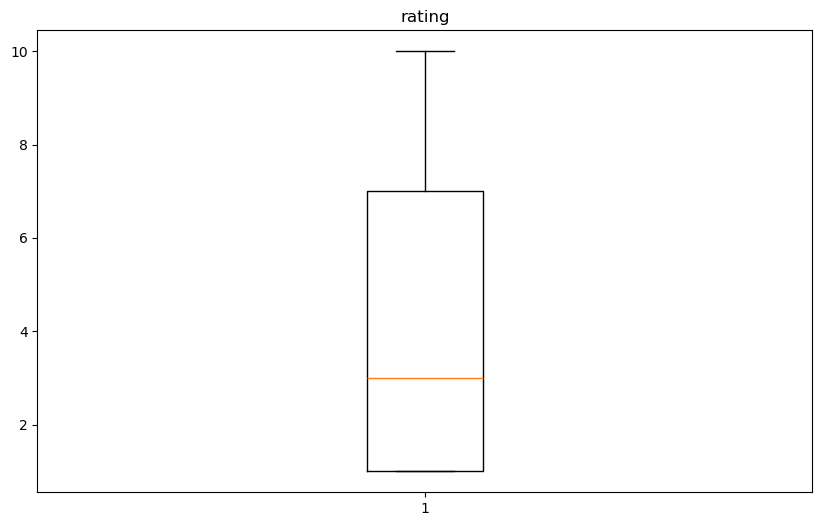

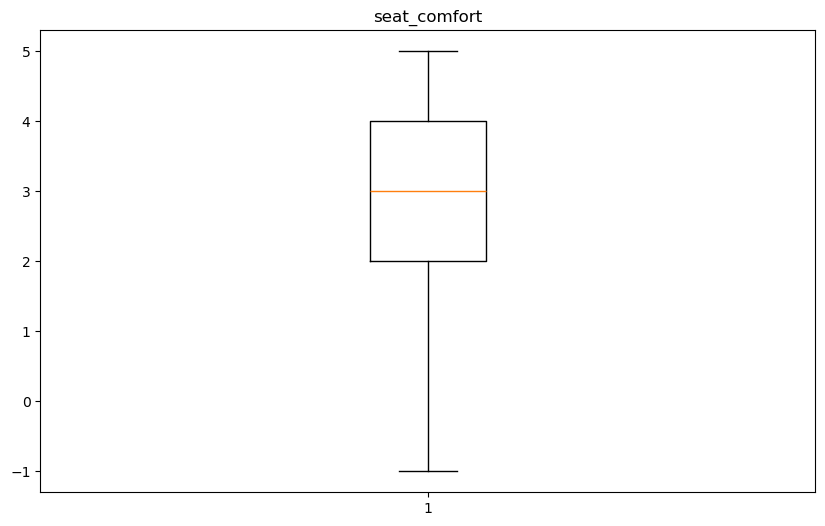

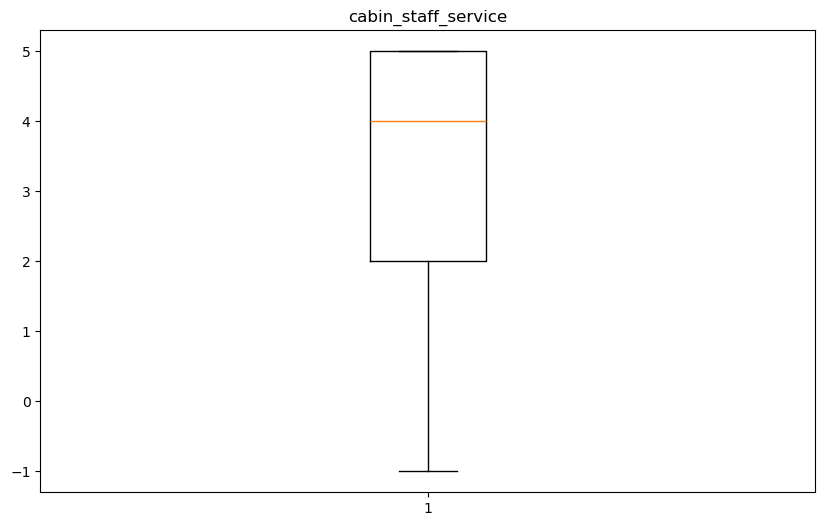

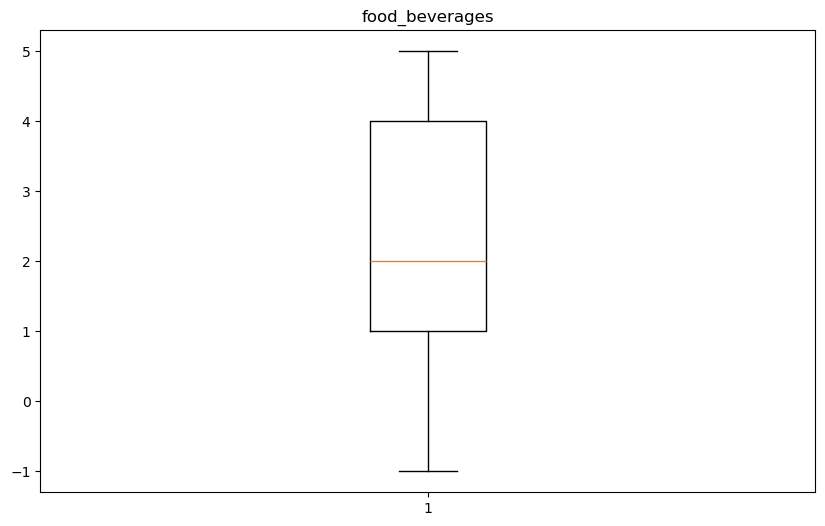

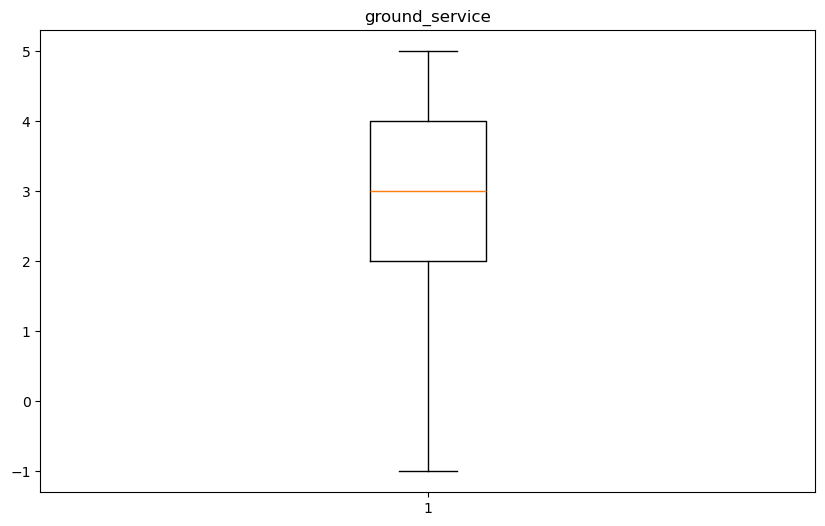

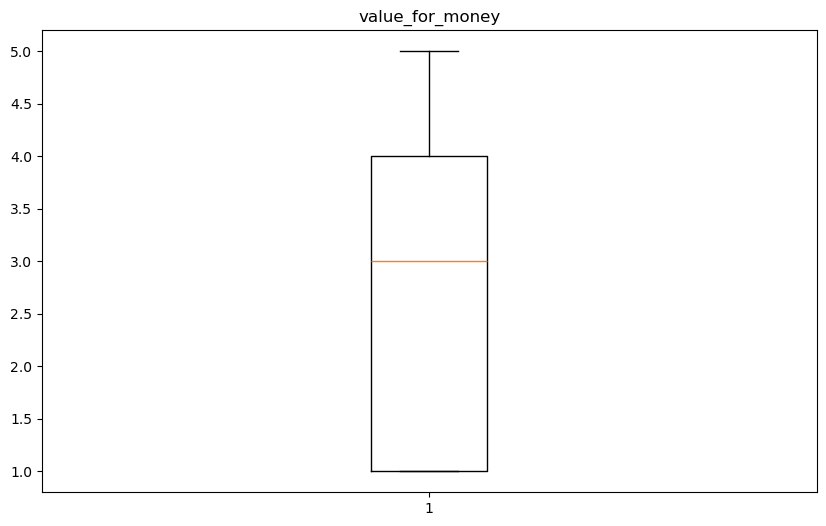

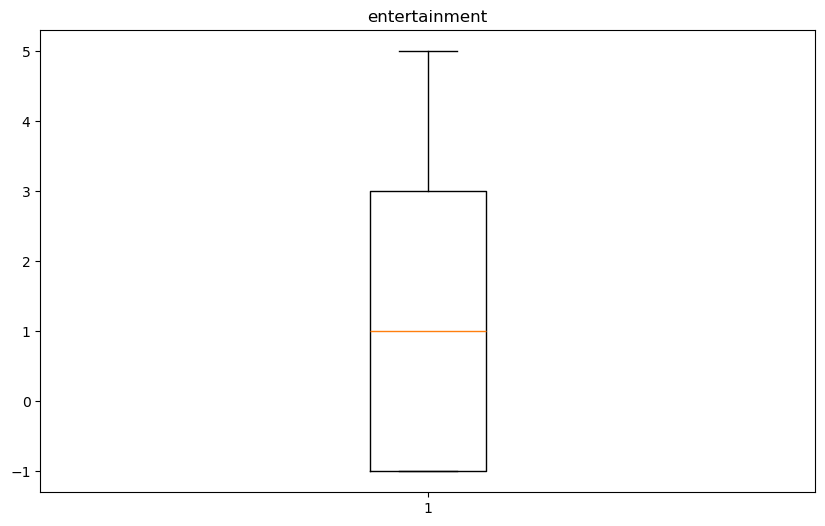

In [243]:
rating_cols = ['rating','seat_comfort','cabin_staff_service','food_beverages','ground_service','value_for_money','entertainment']
for col in rating_cols:
    print(col,ba_reviews[~ba_reviews[col].between(1,5)].shape[0])

for col in rating_cols:
    plt.figure(figsize=(10,6))
    plt.boxplot(ba_reviews[col].dropna())
    plt.title(col)
    plt.show()

In [246]:
df= pd.merge(ba_reviews, countries, left_on='place', right_on='Country', how='left')

In [247]:
df.shape

(1324, 23)

In [248]:
df.isnull().sum()

header                 0
author                 0
date                   0
place                  0
content                0
aircraft               0
traveller_type         0
seat_type              0
route                  0
date_flown             0
recommended            0
trip_verified          0
rating                 0
seat_comfort           0
cabin_staff_service    0
food_beverages         0
ground_service         0
value_for_money        0
entertainment          0
Country                0
Code                   0
Continent              0
Region                 0
dtype: int64

In [251]:
df['Country_clean'] = df['place'].str.split(',').str[-1].str.strip()

In [252]:
df=df.drop(['Country','Code','Continent','Region'],axis=1)
df=df.merge(countries,left_on='Country_clean',right_on='Country',how='left')

In [255]:
import re

def aircraft_family(text):
    if pd.isna(text):
        return None
    t=text.lower()
    if '380' in t:
        return 'A380'
    if '747' in t:
        return 'Boeing 747'
    if '777' in t:
        return 'Boeing 777'
    if '787' in t or 'dreamliner' in t:
        return 'Boeing 787'
    if '767' in t:
        return 'Boeing 767'
    if '737' in t:
        return 'Boeing 737'
    if '350' in t:
        return 'A350'
    if '340' in t:
        return 'A340'
    if '330' in t:
        return 'A330'
    if '321' in t:
        return 'A321'
    if '320' in t:
        return 'A320'
    if '319' in t:
        return 'A319'
    if 'embraer' in t or 'e190' in t or 'e170' in t:
        return 'Embraer'
        return 'Other'

In [256]:
df['aircraft_family'] = df['aircraft'].apply(aircraft_family)

In [257]:
df['aircraft_family'].value_counts()

aircraft_family
Boeing 777    326
A320          288
Boeing 747    186
A380          153
Boeing 787    130
A321           85
A319           71
Boeing 767     29
A350           19
Embraer        14
Boeing 737      8
A340            2
A330            1
Name: count, dtype: int64

In [265]:
aircraft_counts = df['aircraft_family'].value_counts()
valid_aircrafts = aircraft_counts[aircraft_counts >=30].index
df=df[df['aircraft_family'].isin(valid_aircrafts)]

In [266]:
df['csat']=(df['seat_comfort']*0.25
            +df['cabin_staff_service']*0.25
            +df['value_for_money']*0.20
            +df['food_beverages']*0.15
            +df['ground_service']*0.10
            +df['entertainment']*0.05
           )

In [278]:
df['recommended'] = (
    df['recommended']
    .astype(str)
    .str.lower()
    .str.strip()
    .map({'yes': 1, 'no': 0})
)
df['recommended'] = pd.to_numeric(df['recommended'], errors='coerce')


In [279]:
df[['csat','rating','recommended']].corr()

,csat,rating,recommended
csat,1.000000,0.004731,0.777370
rating,0.004731,1.000000,-0.009297
recommended,0.777370,-0.009297,1.000000


In [280]:
df[['csat','rating','recommended']].corr()

,csat,rating,recommended
csat,1.000000,0.004731,0.777370
rating,0.004731,1.000000,-0.009297
recommended,0.777370,-0.009297,1.000000


In [281]:
df['recommended'].unique()

array([0, 1], dtype=int64)

In [282]:
df.groupby('aircraft_family')['csat'].mean().sort_values(ascending=False)

aircraft_family
Boeing 787    3.254231
A380          3.225817
Boeing 777    2.901074
Boeing 747    2.840054
A321          2.552941
A319          2.502113
A320          2.497222
Name: csat, dtype: float64

In [283]:
df.groupby(['Country_clean','aircraft_family'])['csat'].mean()

Country_clean  aircraft_family
Argentina      Boeing 777         1.800000
               Boeing 787         2.350000
Australia      A319               2.633333
               A320               1.387500
               A321               2.450000
                                    ...   
United States  A380               3.083333
               Boeing 747         2.908824
               Boeing 777         2.841667
               Boeing 787         2.950000
Vietnam        A320               2.850000
Name: csat, Length: 162, dtype: float64

In [284]:
import re

In [285]:
import re

def clean_content_full(x):
    try:
        if pd.isna(x) or x is None:
            return ''
        text = str(x)
       
        import unicodedata
        text = unicodedata.normalize('NFKD', text)
       
        text = re.sub(r'[^\x00-\x7F€$£]+', ' ', text)
      
        text = text.lower().strip()
      
        text = re.sub(r'\s+', ' ', text)
        return text
    except:
        return ''

ba_reviews['content'] = ba_reviews['content'].apply(clean_content_full)


In [287]:
def normalize_aircraft(x):
    if pd.isna(x):
        return np.nan
    x=x.lower()
    if 'a320' in x or 'a321' in x or 'a319' in x:
        return 'Airbus A320 Family'
    elif 'a380' in x:
        return 'Airbus A380'
    elif '787' in x:
        return 'Boeing 787'
    elif '777' in x:
        return 'Boeing 777'
    elif '747' in x:
        return 'Boeing 747'
    elif '737' in x:
        return 'Boeing 737'
    else:
        return 'Other'

In [288]:
df['aircraft_family'] = df['aircraft'].apply(normalize_aircraft)

In [290]:
aircraft_counts = df['aircraft_family'].value_counts()
valid_aircrafts = aircraft_counts[aircraft_counts >= 30].index
df = df[df['aircraft_family'].isin(valid_aircraft)]

In [294]:
aircraft_csat = (df.groupby('aircraft_family').agg(avg_csat=('csat','mean'),
                                                   avg_rating=('rating','mean'),
                                                   total_reviews=('csat','count'),
                                                   recommended_rate=('recommended','mean')
                                                  )
                 .reset_index()
                )

In [295]:
df.columns

Index(['header', 'author', 'date', 'place', 'content', 'aircraft',
       'traveller_type', 'seat_type', 'route', 'date_flown', 'recommended',
       'trip_verified', 'rating', 'seat_comfort', 'cabin_staff_service',
       'food_beverages', 'ground_service', 'value_for_money', 'entertainment',
       'Country_clean', 'Country', 'Code', 'Continent', 'Region',
       'aircraft_family', 'csat'],
      dtype='object')

In [299]:
country_aircraft_csat = (df.groupby(['Country','aircraft_family'])
                         .agg(
                             avg_csat=('csat','mean'),
                             reviews=('csat','count')
                         )
                         .reset_index()
                        )

In [300]:
country_aircraft_csat = country_aircraft_csat[country_aircraft_csat['reviews']>=10]

In [304]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')

In [306]:
df['date'].dtype

dtype('<M8[ns]')

In [305]:
df['review_year'] = df['date'].dt.year
df['review_month'] = df['date'].dt.month
df['review_month_name'] = df['date'].dt.month_name()

In [307]:
time_csat = (df.groupby(['review_year','review_month'])
             .agg(avg_csat=('csat','mean'))
             .reset_index()
            )

In [308]:
df[['rating','csat']].corr()

,rating,csat
rating,1.000000,-0.026824
csat,-0.026824,1.000000


In [310]:
df.groupby('recommended')['csat'].mean()

recommended
0    2.117938
1    4.080847
Name: csat, dtype: float64

In [311]:
df.to_csv("ba_reviews_clean.csv", index=False)
aircraft_csat.to_csv("aircraft_csat.csv", index=False)
country_aircraft_csat.to_csv("country_aircraft_csat.csv", index=False)
time_csat.to_csv("time_csat.csv", index=False)